# Proyecto Final – Sistemas Inteligentes
## Segmentación comercial de ventas de una cafetería-restaurante (Aprendizaje No Supervisado)
**Modelo 1: K-means**

Este cuaderno recorre el proceso de Machine Learning completo para el primer modelo:
1. Carga del dataset
2. Análisis exploratorio de datos (EDA)
3. Limpieza de datos
4. Preparación del dataset para modelado
5. Primer modelo no supervisado: **K-means**
6. Evaluación del modelo 1 y perfilado de los clústeres

> **Antes de ejecutar:** sube el archivo `ventas_cafeteria.csv` al entorno de Colab (panel de archivos de la izquierda) o ejecuta la celda de carga y selecciónalo cuando se te pida.

## 0. Configuración

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
SEED = 42   # semilla para reproducibilidad

## 1. Carga del dataset

In [2]:
ARCHIVO = "ventas_cafeteria.csv"

# Si el archivo no está en el entorno, en Colab se pedirá subirlo
if not os.path.exists(ARCHIVO):
    try:
        from google.colab import files
        print("Selecciona el archivo ventas_cafeteria.csv")
        files.upload()
    except ImportError:
        raise FileNotFoundError(f"No se encontró {ARCHIVO} en la carpeta actual.")

df = pd.read_csv(ARCHIVO)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(10)

Filas: 1520 | Columnas: 9


,ID_Ticket,Fecha,Dia_Semana,Hora_Dia,Monto_Total,Cantidad_Items,Para_Llevar,Tiempo_Permanencia_Min,Metodo_Pago
0,T0001,2026-06-01,1,9,16.5,3,1,2.0,Tarjeta
1,T0002,2026-06-01,1,10,13.3,2,0,11.0,Efectivo
2,T0003,2026-06-01,1,12,14.0,1,0,32.0,Plin
3,T0004,2026-06-01,1,12,36.9,4,0,13.0,Plin
4,T0005,2026-06-01,1,12,9.4,2,0,15.0,Yape
5,T0006,2026-06-01,1,12,28.3,3,0,53.0,Efectivo
6,T0007,2026-06-01,1,13,31.9,4,0,24.0,Plin
7,T0008,2026-06-01,1,13,32.8,4,0,47.0,Efectivo
8,T0009,2026-06-01,1,13,31.3,4,0,57.0,Yape
9,T0010,2026-06-01,1,14,39.4,4,0,43.0,Yape


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Ticket               1520 non-null   str    
 1   Fecha                   1520 non-null   str    
 2   Dia_Semana              1520 non-null   int64  
 3   Hora_Dia                1520 non-null   int64  
 4   Monto_Total             1520 non-null   float64
 5   Cantidad_Items          1520 non-null   int64  
 6   Para_Llevar             1520 non-null   int64  
 7   Tiempo_Permanencia_Min  1475 non-null   float64
 8   Metodo_Pago             1498 non-null   str    
dtypes: float64(2), int64(4), str(3)
memory usage: 107.0 KB


**Descripción de las variables**

| Variable | Descripción |
|---|---|
| `ID_Ticket` | Identificador único de la boleta |
| `Fecha` | Fecha de la venta (AAAA-MM-DD) |
| `Dia_Semana` | Día de la semana (1 = lunes ... 7 = domingo) |
| `Hora_Dia` | Hora del pedido en formato 24 h (ej. 14 = 2:00 p. m.) |
| `Monto_Total` | Monto total de la boleta (S/) |
| `Cantidad_Items` | Cantidad de productos del pedido |
| `Para_Llevar` | 1 = pedido para llevar, 0 = consumo en el local |
| `Tiempo_Permanencia_Min` | Minutos que el cliente permaneció en el local |
| `Metodo_Pago` | Efectivo, Yape, Plin o Tarjeta (variable categórica) |

## 2. Análisis exploratorio de datos (EDA)

In [4]:
df.describe().round(2)

,Dia_Semana,Hora_Dia,Monto_Total,Cantidad_Items,Para_Llevar,Tiempo_Permanencia_Min
count,1520.00,1520.00,1520.00,1520.00,1520.00,1475.00
mean,3.89,14.39,35.30,3.19,0.23,32.22
std,1.87,4.42,41.60,2.71,0.42,24.40
min,1.00,3.00,-15.00,0.00,0.00,-20.00
25%,2.00,10.00,12.78,2.00,0.00,12.50
50%,4.00,14.00,18.75,2.00,0.00,28.00
75%,5.00,18.00,39.40,4.00,0.00,44.00
max,7.00,25.00,519.50,30.00,1.00,121.00


In [5]:
# Valores nulos y duplicados
nulos = df.isna().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0].to_string())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"IDs de ticket repetidos: {df['ID_Ticket'].duplicated().sum()}")

Valores nulos por columna:
Tiempo_Permanencia_Min    45
Metodo_Pago               22

Filas duplicadas: 12
IDs de ticket repetidos: 12


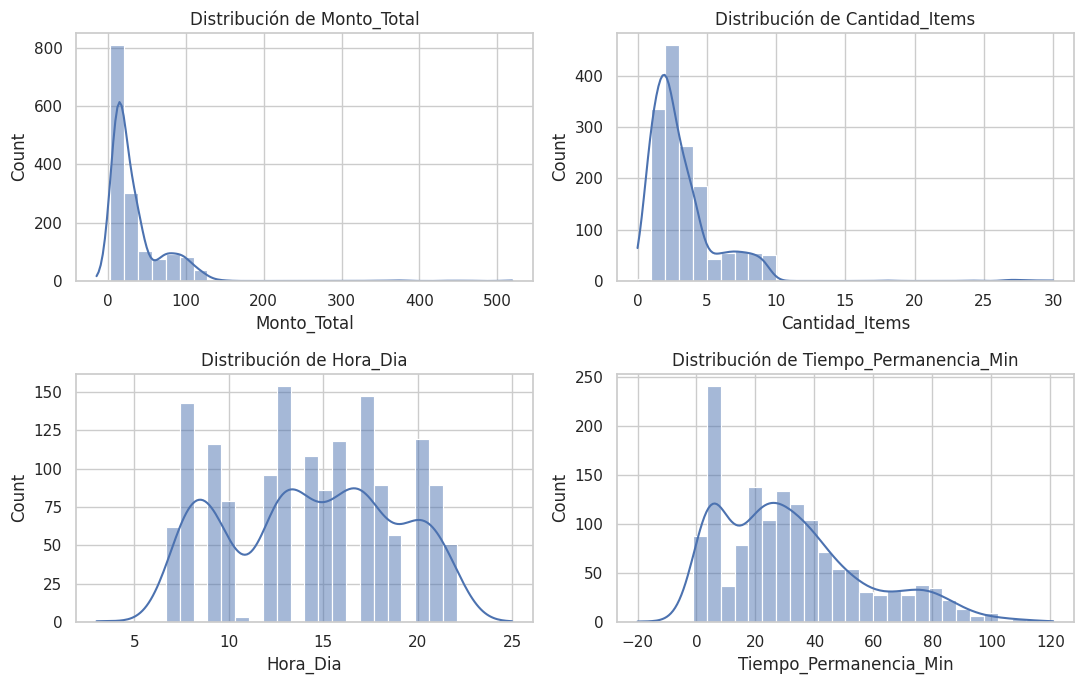

In [6]:
# Distribución de las variables numéricas
num_cols = ["Monto_Total", "Cantidad_Items", "Hora_Dia", "Tiempo_Permanencia_Min"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

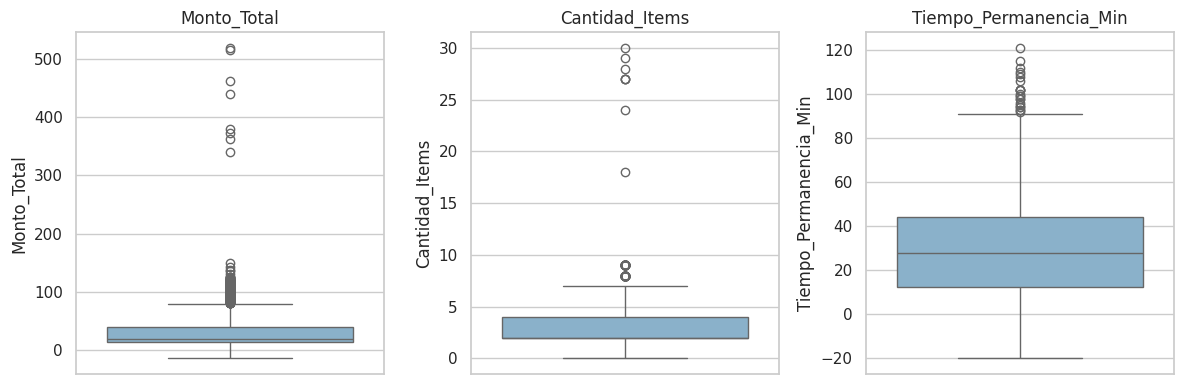

In [7]:
# Boxplots para detectar valores atípicos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["Monto_Total", "Cantidad_Items", "Tiempo_Permanencia_Min"]):
    sns.boxplot(y=df[col], ax=ax, color="#7fb3d5")
    ax.set_title(col)
plt.tight_layout()
plt.show()

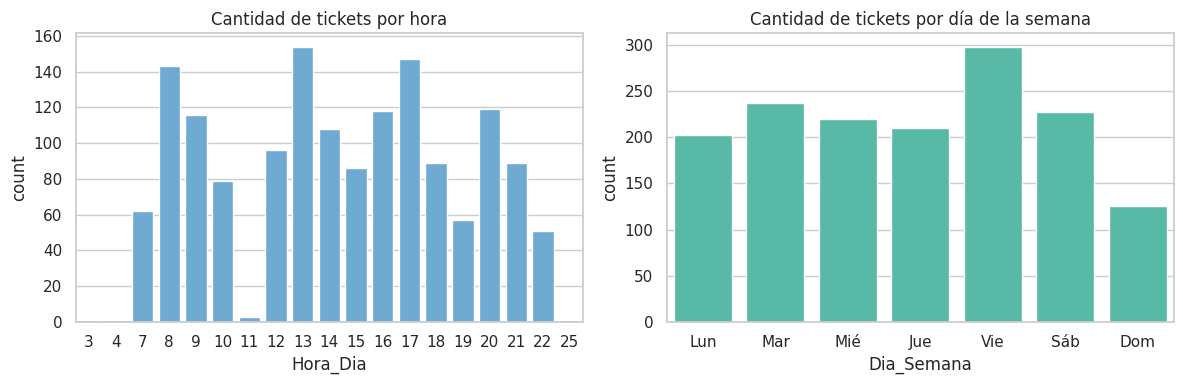

In [8]:
# Comportamiento de las ventas por hora y por día
nombres_dia = {1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Hora_Dia", data=df, ax=axes[0], color="#5dade2")
axes[0].set_title("Cantidad de tickets por hora")
sns.countplot(x=df["Dia_Semana"].map(nombres_dia), data=df, ax=axes[1],
              order=list(nombres_dia.values()), color="#48c9b0")
axes[1].set_title("Cantidad de tickets por día de la semana")
plt.tight_layout()
plt.show()

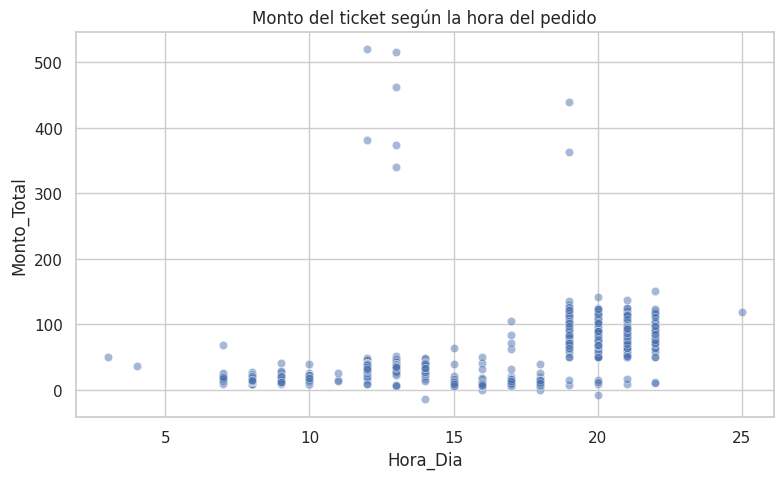

In [9]:
# Relación entre monto y hora del día
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Hora_Dia", y="Monto_Total", alpha=0.5)
plt.title("Monto del ticket según la hora del pedido")
plt.show()

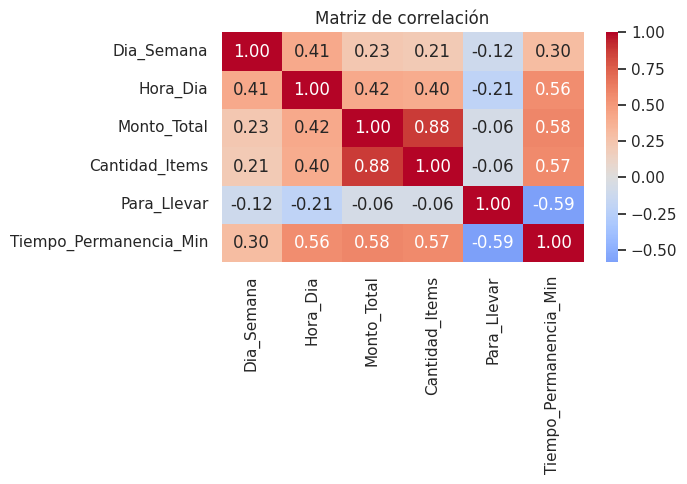

In [10]:
# Correlación entre variables numéricas
plt.figure(figsize=(7, 5))
sns.heatmap(df[["Dia_Semana", "Hora_Dia", "Monto_Total", "Cantidad_Items",
                "Para_Llevar", "Tiempo_Permanencia_Min"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

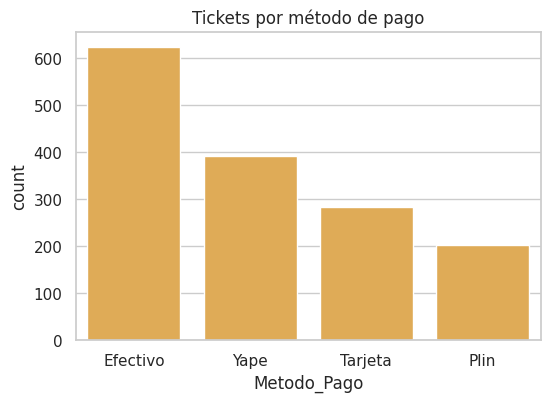

In [11]:
# Variable categórica: método de pago
plt.figure(figsize=(6, 4))
sns.countplot(x="Metodo_Pago", data=df, order=df["Metodo_Pago"].value_counts().index, color="#f5b041")
plt.title("Tickets por método de pago")
plt.show()

**Hallazgos del EDA**
- Las ventas se concentran en franjas horarias bien definidas (mañana, mediodía, tarde y noche).
- `Monto_Total` y `Cantidad_Items` presentan una asimetría positiva: hay pocos tickets muy grandes.
- Existen valores nulos, filas duplicadas y registros con valores imposibles (montos negativos, horas fuera del horario, etc.) que se tratarán en la limpieza.

## 3. Limpieza de datos

In [12]:
n_inicial = len(df)
resumen = {}

# 3.1 Duplicados
resumen["Duplicados eliminados"] = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# 3.2 Valores inválidos según reglas del negocio
#     - Monto y cantidad de ítems deben ser positivos
#     - El local atiende de 7:00 a 22:59 (Hora_Dia entre 7 y 22)
#     - El tiempo de permanencia no puede ser negativo
invalidos = ((df["Monto_Total"] <= 0) | (df["Cantidad_Items"] <= 0) |
             (~df["Hora_Dia"].between(7, 22)) | (df["Tiempo_Permanencia_Min"] < 0))
resumen["Registros inválidos eliminados"] = int(invalidos.sum())
df = df[~invalidos].reset_index(drop=True)

Límite superior por IQR (Q3 + 1.5·IQR): S/ 79.30
Tickets sobre ese límite: 190 (12.7% del total)


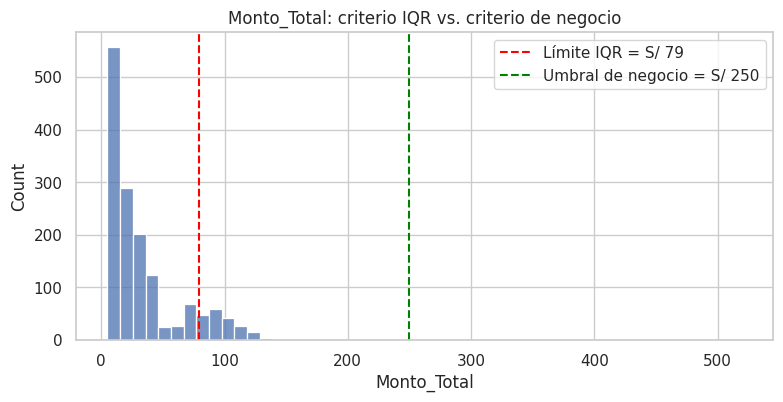

In [13]:
# 3.3 Valores atípicos en Monto_Total
q1, q3 = df["Monto_Total"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_iqr = q3 + 1.5 * iqr
n_iqr = (df["Monto_Total"] > limite_iqr).sum()
print(f"Límite superior por IQR (Q3 + 1.5·IQR): S/ {limite_iqr:.2f}")
print(f"Tickets sobre ese límite: {n_iqr} ({n_iqr / len(df):.1%} del total)")

plt.figure(figsize=(9, 4))
sns.histplot(df["Monto_Total"], bins=50)
plt.axvline(limite_iqr, color="red", linestyle="--", label=f"Límite IQR = S/ {limite_iqr:.0f}")
plt.axvline(250, color="green", linestyle="--", label="Umbral de negocio = S/ 250")
plt.legend(); plt.title("Monto_Total: criterio IQR vs. criterio de negocio")
plt.show()

El criterio IQR marcaría como atípicos a cerca de un 12 % de los tickets, que en realidad corresponden a **consumos grupales legítimos** (el segmento de mayor valor). Eliminarlos haría desaparecer un perfil de cliente real.
Por eso se aplica un **criterio de negocio**: se excluyen solo los pedidos con monto mayor a **S/ 250**, que corresponden a pedidos corporativos o eventos y no representan el consumo típico.

In [14]:
UMBRAL_MONTO = 250
extremos = df["Monto_Total"] > UMBRAL_MONTO
resumen["Pedidos extremos eliminados (> S/ 250)"] = int(extremos.sum())
df = df[~extremos].reset_index(drop=True)

# 3.4 Valores nulos
resumen["Nulos imputados en Tiempo_Permanencia_Min (mediana)"] = int(df["Tiempo_Permanencia_Min"].isna().sum())
resumen["Nulos imputados en Metodo_Pago (moda)"] = int(df["Metodo_Pago"].isna().sum())
df["Tiempo_Permanencia_Min"] = df["Tiempo_Permanencia_Min"].fillna(df["Tiempo_Permanencia_Min"].median())
df["Metodo_Pago"] = df["Metodo_Pago"].fillna(df["Metodo_Pago"].mode()[0])

assert df.isna().sum().sum() == 0

print(pd.Series(resumen).to_string())
print(f"\nRegistros iniciales: {n_inicial}  ->  registros finales: {len(df)}")

Duplicados eliminados                                  12
Registros inválidos eliminados                         14
Pedidos extremos eliminados (> S/ 250)                  8
Nulos imputados en Tiempo_Permanencia_Min (mediana)    45
Nulos imputados en Metodo_Pago (moda)                  22

Registros iniciales: 1520  ->  registros finales: 1486


## 4. Preparación del dataset para modelado

- **Ingeniería de variables:** `Dia_Semana` (1–7) se transforma en `Es_FinDeSemana` (1 = sábado o domingo). K-means usa distancias euclidianas y un valor numérico 1–7 asumiría que el lunes y el domingo están "lejos", lo cual no refleja el comportamiento real del negocio.
- **Codificación de variables categóricas:** `Metodo_Pago` se codifica con *one-hot encoding*. No se usa para agrupar (se quiere segmentar por comportamiento de compra), pero queda disponible para interpretar los clústeres.
- **Escalado:** se aplica `StandardScaler` para que el monto (decenas de soles) no domine sobre variables de escala pequeña como la cantidad de ítems.

In [15]:
# Variable derivada
df["Es_FinDeSemana"] = (df["Dia_Semana"] >= 6).astype(int)

# Codificación one-hot de la variable categórica
df = pd.get_dummies(df, columns=["Metodo_Pago"], prefix="Pago", dtype=int)

# Variables que usará el modelo (comportamiento de compra)
FEATURES = ["Monto_Total", "Cantidad_Items", "Hora_Dia", "Es_FinDeSemana"]
X = df[FEATURES].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables del modelo:", FEATURES)
print("Forma de la matriz escalada:", X_scaled.shape)
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)

Variables del modelo: ['Monto_Total', 'Cantidad_Items', 'Hora_Dia', 'Es_FinDeSemana']
Forma de la matriz escalada: (1486, 4)


,Monto_Total,Cantidad_Items,Hora_Dia,Es_FinDeSemana
count,1486.00,1486.00,1486.00,1486.00
mean,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-0.94,-0.98,-1.69,-0.55
25%,-0.68,-0.51,-1.00,-0.55
50%,-0.49,-0.51,0.13,-0.55
75%,0.19,0.44,0.82,-0.55
max,3.87,2.81,1.72,1.81


## 5. Primer modelo: K-means

K-means requiere definir el número de clústeres **k** con anticipación. Para elegirlo se evalúa un rango de k entre 2 y 10 con cuatro criterios:
- **Inercia (WCSS)** y método del codo
- **Coeficiente de silueta** (más alto es mejor)
- **Índice de Davies-Bouldin** (más bajo es mejor)
- **Índice de Calinski-Harabasz** (más alto es mejor)

In [16]:
resultados = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED).fit(X_scaled)
    resultados.append({
        "k": k,
        "Inercia": km.inertia_,
        "Silueta": silhouette_score(X_scaled, km.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, km.labels_),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, km.labels_),
    })
res = pd.DataFrame(resultados).set_index("k")
res.round(3)

,Inercia,Silueta,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,2777.634,0.570,0.767,1691.687
3,1908.654,0.526,0.689,1567.707
4,1417.915,0.468,0.750,1576.883
5,992.020,0.493,0.791,1848.219
6,711.213,0.562,0.692,2177.835
7,620.833,0.548,0.754,2113.550
8,544.155,0.550,0.802,2095.248
9,490.541,0.538,0.899,2052.519
10,449.396,0.500,0.897,2005.171


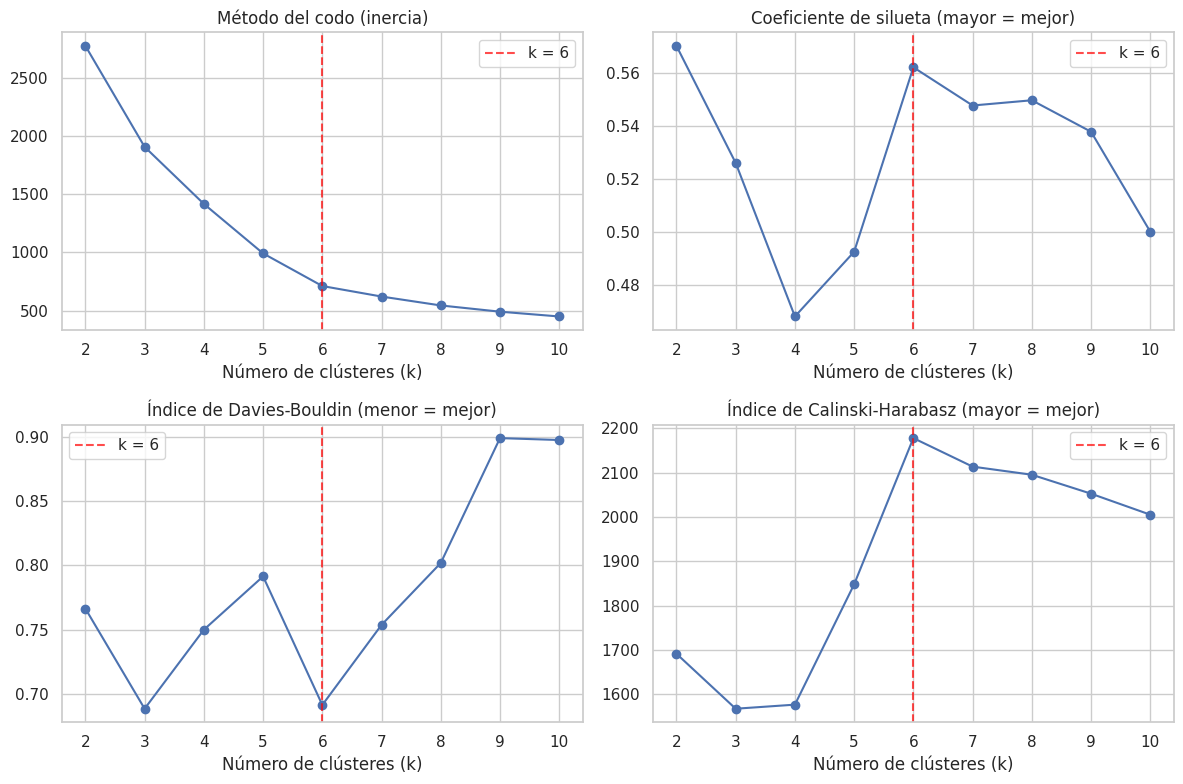

In [17]:
K_ELEGIDO = 6

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
graficos = [("Inercia", "Método del codo (inercia)"),
            ("Silueta", "Coeficiente de silueta (mayor = mejor)"),
            ("Davies-Bouldin", "Índice de Davies-Bouldin (menor = mejor)"),
            ("Calinski-Harabasz", "Índice de Calinski-Harabasz (mayor = mejor)")]
for ax, (col, titulo) in zip(axes.ravel(), graficos):
    ax.plot(res.index, res[col], marker="o")
    ax.axvline(K_ELEGIDO, color="red", linestyle="--", alpha=0.7, label=f"k = {K_ELEGIDO}")
    ax.set_title(titulo); ax.set_xlabel("Número de clústeres (k)"); ax.legend()
plt.tight_layout()
plt.show()

**Justificación de k = 6** (ver la tabla y los gráficos anteriores):
- **Codo:** la inercia baja con fuerza hasta k = 6 y a partir de ahí las mejoras son marginales.
- **Calinski-Harabasz:** alcanza su valor máximo en k = 6.
- **Davies-Bouldin:** en k = 6 toma uno de los valores más bajos (mejor separación).
- **Silueta:** en k = 6 es alta (> 0.5, estructura razonable). Con k = 2 la silueta es ligeramente mayor, pero solo separa "ticket alto" de "ticket bajo", una segmentación demasiado gruesa para tomar decisiones comerciales.
- **Interpretabilidad:** con k = 6 cada clúster corresponde a un perfil de consumo claro (turno + tipo de día + valor del ticket).

In [18]:
# Estabilidad: ¿el resultado cambia con otra semilla de inicialización?
base = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=SEED).fit(X_scaled).labels_
for s in [1, 7, 21, 99]:
    otra = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=s).fit(X_scaled).labels_
    print(f"Semilla {s:>2}: ARI frente a la partición base = {adjusted_rand_score(base, otra):.3f}")

Semilla  1: ARI frente a la partición base = 1.000
Semilla  7: ARI frente a la partición base = 1.000
Semilla 21: ARI frente a la partición base = 1.000
Semilla 99: ARI frente a la partición base = 1.000


In [19]:
# Entrenamiento del modelo final
kmeans = KMeans(n_clusters=K_ELEGIDO,      # k justificado arriba
                init="k-means++",         # inicialización inteligente de centroides
                n_init=10,                # 10 inicializaciones, se conserva la mejor
                max_iter=300,
                random_state=SEED)        # distancia: euclidiana (por defecto en K-means)
kmeans.fit(X_scaled)

df["Cluster"] = kmeans.labels_
print("Convergió en", kmeans.n_iter_, "iteraciones")
print("Inercia final:", round(kmeans.inertia_, 1))
print("\nTickets por clúster:")
print(df["Cluster"].value_counts().sort_index().to_string())

Convergió en 3 iteraciones
Inercia final: 711.2

Tickets por clúster:
Cluster
0    129
1    326
2    177
3    170
4    374
5    310


## 6. Evaluación del modelo 1 y perfilado de clústeres

In [20]:
sil = silhouette_score(X_scaled, df["Cluster"])
db = davies_bouldin_score(X_scaled, df["Cluster"])
ch = calinski_harabasz_score(X_scaled, df["Cluster"])
print(f"Coeficiente de silueta : {sil:.3f}")
print(f"Índice Davies-Bouldin  : {db:.3f}")
print(f"Índice Calinski-Harabasz: {ch:.1f}")

Coeficiente de silueta : 0.562
Índice Davies-Bouldin  : 0.692
Índice Calinski-Harabasz: 2177.8


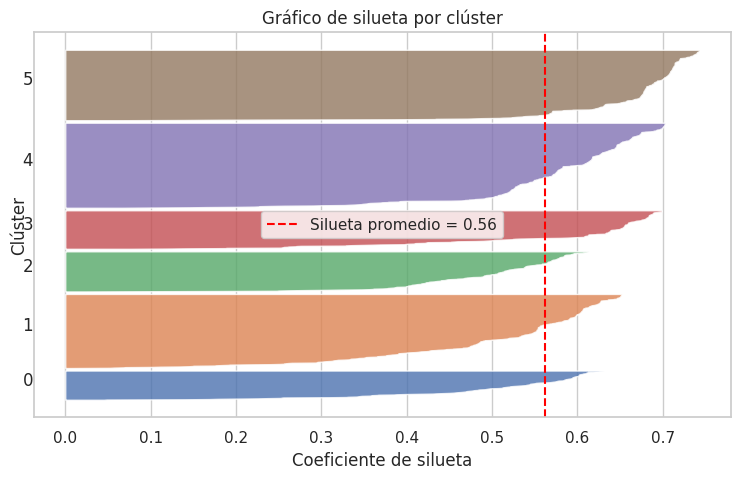

In [21]:
# Silueta por clúster
sil_muestras = silhouette_samples(X_scaled, df["Cluster"])
fig, ax = plt.subplots(figsize=(9, 5))
y_inf = 10
for c in range(K_ELEGIDO):
    vals = np.sort(sil_muestras[df["Cluster"] == c])
    y_sup = y_inf + len(vals)
    ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals, alpha=0.8)
    ax.text(-0.05, y_inf + 0.5 * len(vals), str(c))
    y_inf = y_sup + 10
ax.axvline(sil, color="red", linestyle="--", label=f"Silueta promedio = {sil:.2f}")
ax.set_xlabel("Coeficiente de silueta"); ax.set_ylabel("Clúster"); ax.set_yticks([])
ax.set_title("Gráfico de silueta por clúster"); ax.legend()
plt.show()

Varianza explicada por PC1 y PC2: [63.  20.6] %


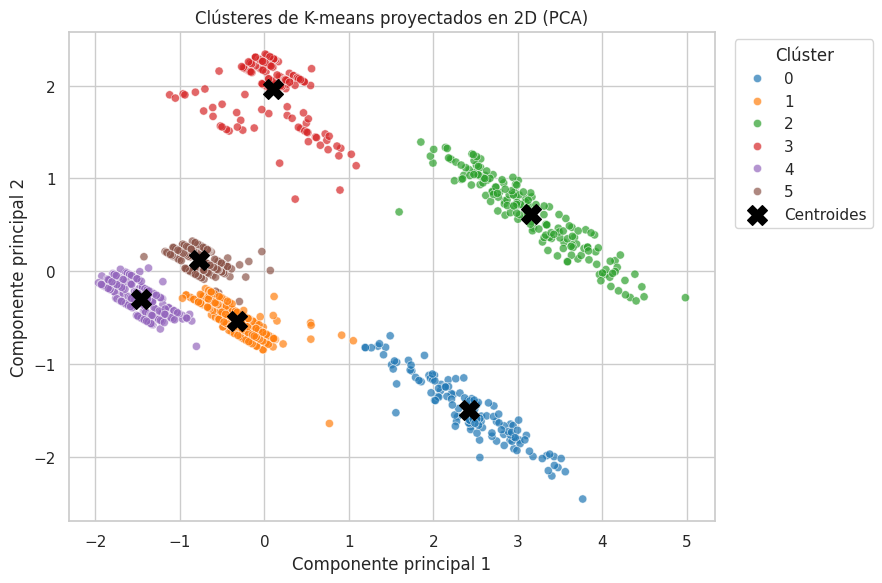

In [22]:
# Visualización en 2D con PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print("Varianza explicada por PC1 y PC2:", (pca.explained_variance_ratio_ * 100).round(1), "%")

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Cluster"], palette="tab10", alpha=0.7, s=35)
centros_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centros_pca[:, 0], centros_pca[:, 1], c="black", marker="X", s=200, label="Centroides")
plt.title("Clústeres de K-means proyectados en 2D (PCA)")
plt.xlabel("Componente principal 1"); plt.ylabel("Componente principal 2")
plt.legend(title="Clúster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

In [23]:
# Perfil de cada clúster
perfil = df.groupby("Cluster").agg(
    Tickets=("Cluster", "size"),
    Monto_prom=("Monto_Total", "mean"),
    Items_prom=("Cantidad_Items", "mean"),
    Hora_prom=("Hora_Dia", "mean"),
    Pct_FinDeSemana=("Es_FinDeSemana", "mean"),
    Pct_ParaLlevar=("Para_Llevar", "mean"),
    Permanencia_prom=("Tiempo_Permanencia_Min", "mean"),
)
perfil["Pct_Tickets"] = perfil["Tickets"] / perfil["Tickets"].sum()

# Nombre descriptivo del clúster a partir de su perfil
def nombrar(fila):
    h = fila["Hora_prom"]
    turno = ("Desayuno" if h < 11 else "Almuerzo" if h < 14.5
             else "Merienda / tarde" if h < 19 else "Cena")
    dia = "fin de semana" if fila["Pct_FinDeSemana"] > 0.5 else "entre semana"
    return f"{turno} {dia}"

perfil["Nombre"] = perfil.apply(nombrar, axis=1)
nombres_cluster = perfil["Nombre"].to_dict()
perfil.round(2)

,Tickets,Monto_prom,Items_prom,Hora_prom,Pct_FinDeSemana,Pct_ParaLlevar,Permanencia_prom,Pct_Tickets,Nombre
Cluster,,,,,,,,,
0,129,84.27,6.90,20.44,0.0,0.07,65.08,0.09,Cena entre semana
1,326,34.46,3.10,13.13,0.0,0.25,32.23,0.22,Almuerzo entre semana
2,177,86.97,6.24,20.37,1.0,0.07,63.68,0.12,Cena fin de semana
3,170,15.78,1.90,15.04,1.0,0.22,23.85,0.11,Merienda / tarde fin de semana
4,374,16.20,2.02,8.56,0.0,0.34,16.29,0.25,Desayuno entre semana
5,310,10.69,1.54,16.56,0.0,0.23,23.30,0.21,Merienda / tarde entre semana


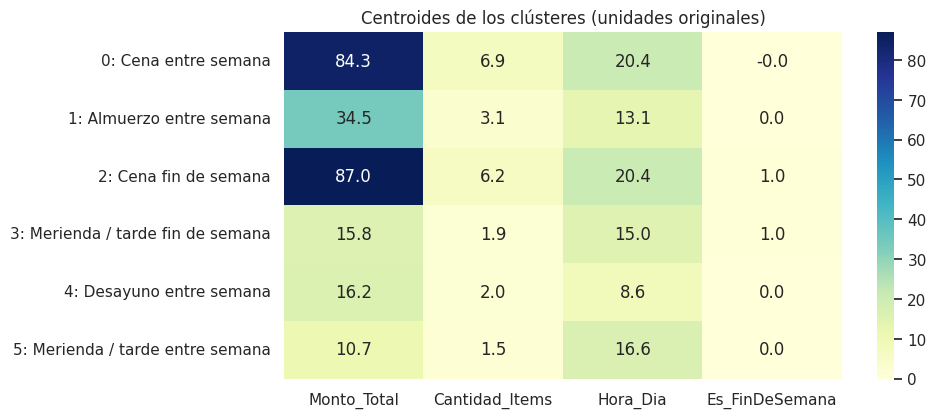

In [24]:
# Mapa de calor de los centroides (en unidades originales)
centroides = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=FEATURES)
centroides.index = [f"{c}: {nombres_cluster[c]}" for c in centroides.index]
plt.figure(figsize=(9, 4.5))
sns.heatmap(centroides.round(1), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Centroides de los clústeres (unidades originales)")
plt.show()

In [25]:
# Método de pago por clúster (variable no usada para agrupar)
pagos = [c for c in df.columns if c.startswith("Pago_")]
(df.groupby("Cluster")[pagos].mean() * 100).round(1)

,Pago_Efectivo,Pago_Plin,Pago_Tarjeta,Pago_Yape
Cluster,,,,
0,32.6,14.7,31.8,20.9
1,43.9,14.1,18.4,23.6
2,30.5,15.8,28.8,24.9
3,45.3,12.4,14.7,27.6
4,44.4,12.6,12.6,30.5
5,50.3,11.9,13.9,23.9


**Interpretación preliminar**
- Los clústeres se organizan principalmente por **turno del día** y por **valor del ticket**.
- Existe un clúster de **cena con tickets altos y varios ítems** (consumo grupal), separado en días de semana y fin de semana.
- Los turnos de desayuno, almuerzo y merienda muestran tickets de valor bajo a medio, con comportamientos claramente distintos entre sí.

## 7. Guardado de artefactos (para el despliegue)

In [26]:
# El modelo entrenado y el escalador se guardan para usarlos después en la API / aplicación
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")
with open("config_modelo.json", "w", encoding="utf-8") as f:
    json.dump({"features": FEATURES, "k": K_ELEGIDO,
               "nombres_cluster": {int(k): v for k, v in nombres_cluster.items()}},
              f, ensure_ascii=False, indent=2)

df.to_csv("ventas_cafeteria_limpio.csv", index=False)
print("Archivos guardados: scaler.pkl, kmeans_model.pkl, config_modelo.json, ventas_cafeteria_limpio.csv")

# En Google Colab puedes descargarlos con:
# from google.colab import files
# for a in ["scaler.pkl", "kmeans_model.pkl", "config_modelo.json"]: files.download(a)

Archivos guardados: scaler.pkl, kmeans_model.pkl, config_modelo.json, ventas_cafeteria_limpio.csv


In [27]:
# Prueba de inferencia con un ticket nuevo (misma transformación que en el entrenamiento)
def predecir_ticket(monto, items, hora, dia_semana):
    fila = pd.DataFrame([{
        "Monto_Total": monto, "Cantidad_Items": items, "Hora_Dia": hora,
        "Es_FinDeSemana": int(dia_semana >= 6)}])[FEATURES]
    c = int(kmeans.predict(scaler.transform(fila))[0])
    return c, nombres_cluster[c]

# Ejemplo: venta de S/ 85, 4 ítems, sábado (6) a las 21:00
print(predecir_ticket(85.0, 4, 21, 6))

(2, 'Cena fin de semana')
